In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import models, layers
import matplotlib.pyplot as plt
import numpy as np
import random

In [2]:
with np.load("mnist.npz") as data:
    x_train,y_train,x_test,y_test= data['x_train'],data['y_train'],data['x_test'],data["y_test"]

In [3]:
x_train.shape

(60000, 28, 28)

In [4]:
y_train.shape

(60000,)

In [5]:
x_test.shape

(10000, 28, 28)

<function matplotlib.pyplot.show(close=None, block=None)>

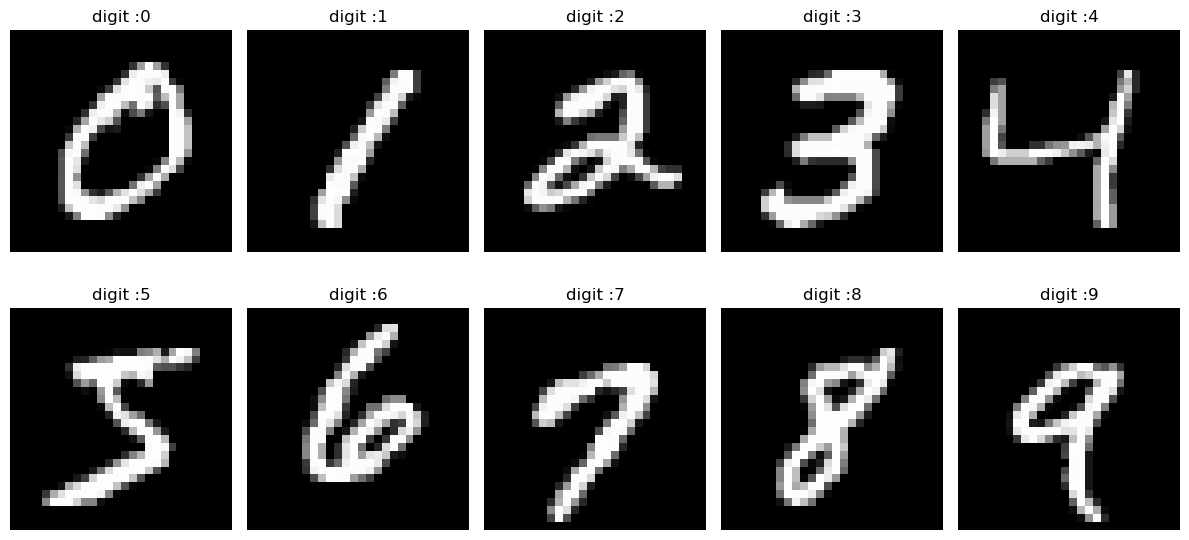

In [6]:
plt.figure(figsize=(12,6))
for i in range(10):
    idx= np.where(y_train==i)[0][0]
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[idx],cmap='grey')
    plt.title(f"digit :{i}")
    plt.axis("off")
plt.tight_layout()
plt.show
    

In [8]:
max_pixel_value=max( x_train.max(),x_test.max())
x_train=x_train.astype("float")/max_pixel_value
x_test=x_test.astype("float")/max_pixel_value

In [12]:
model=models.Sequential([
    layers.Input(shape=(28,28)),
    layers.Flatten(),
    layers.Dense(256,activation="relu"),
    layers.Dense(128,activation="tanh"),
    layers.Dense(64,activation="relu"),
    layers.Dense(10,activation="softmax")
    
])

In [13]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [21]:
early_stop=keras.callbacks.EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True)
history=model.fit(x_train,y_train, epochs=50,validation_data=(x_test,y_test),callbacks=[early_stop])

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7347 - loss: 1.0120 - val_accuracy: 0.9245 - val_loss: 0.2714
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9268 - loss: 0.2535 - val_accuracy: 0.9403 - val_loss: 0.2046
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9444 - loss: 0.1903 - val_accuracy: 0.9505 - val_loss: 0.1649
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9553 - loss: 0.1544 - val_accuracy: 0.9584 - val_loss: 0.1411
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9609 - loss: 0.1321 - val_accuracy: 0.9629 - val_loss: 0.1232
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9670 - loss: 0.1125 - val_accuracy: 0.9662 - val_loss: 0.1116
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9725 - loss: 0.0967 - val_accuracy: 0.9687 - val_loss: 0.1065
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9764 - loss: 0.

In [23]:
train_loss,train_acc=model.evaluate(x_train,y_train)
print(f"train_loss is : {train_loss:.3f}")
print(f"train_accuracy is :{train_acc*100:.3f}%")

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9965 - loss: 0.0181
train_loss is : 0.018
train_accuracy is :99.663%


In [24]:
test_loss,test_acc=model.evaluate(x_test,y_test)
print(f"test_loss is :{test_loss:.3f}")
print(f"test_accuracy is :{test_acc*100:.3f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9761 - loss: 0.0783
test_loss is :0.067
test_accuracy is :97.890%


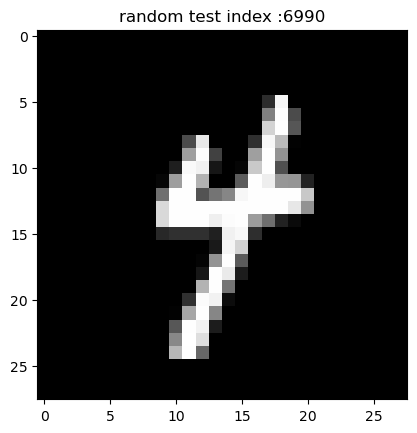

In [25]:
n=random.randint(0,len(x_test)-1)
plt.imshow(x_test[n],cmap='gray')
plt.title(f"random test index :{n}")
plt.show()


In [28]:
predicted_values=model.predict(x_test)
predicted_class=np.argmax(predicted_values[n])
print(f"the predicted value of handwritten digit is : {predicted_class}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
the predicted value of handwritten digit is : 4


In [30]:
list(history.history.keys())

['accuracy', 'loss', 'val_accuracy', 'val_loss']

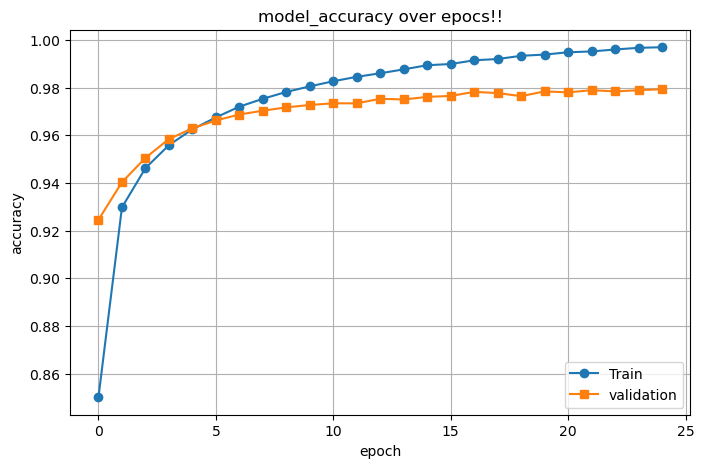

In [33]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],marker='o')
plt.plot(history.history['val_accuracy'],marker='s')
plt.title("model_accuracy over epocs!!")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend(['Train','validation'],loc='lower right')
plt.grid(True)
plt.show()